In [2]:
from pathlib import Path
import os
import sys
import pickle

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
%matplotlib inline

from sklearn.metrics import accuracy_score, confusion_matrix

In [18]:
root_path = "/Users/kautsarg/Documents/Final Project/Run Data/trial test data/"
sample_name = "D20250811_E00_C00_F4500KHz_U_Sample_6"
exp_path = os.path.join(root_path, sample_name)
data_path = os.path.join(exp_path, "classification_performances_with_proba.pkl")
with open(data_path, 'rb') as f:
    result_data = pickle.load(f)

In [3]:
# %load_ext autoreload
# %autoreload
# from outlier_utils import unsupervised_line_fitting, build_interactive_msc_html

# training_data_path = os.path.join(exp_path, "curve_for_training_latest.pkl")
# interactive_plot_path = os.path.join(exp_path, "msc_outlier")

# os.makedirs(interactive_plot_path, exist_ok=True)

# print(f"[*] Loading data from: {training_data_path}")
# with open(training_data_path, 'rb') as f:
#     training_data = pickle.load(f)

# dataset_names = training_data["dataset_name"]
# dataset_curves = training_data["dataset"]
# kinetic_features = training_data["kinetic_features"]
# Y_well = training_data["Y_well"]
# ref_curves = dataset_curves[0]

# linear_feature_combinations = training_data.get("linear_feature_combinations", [])

# msc_configs = [
#     ("msc_linear_0.05", 0.05, linear_feature_combinations),
#     ("msc_linear_0.01", 0.01, linear_feature_combinations),
#     ("msc_linear_0.001", 0.001, linear_feature_combinations),
#     ("msc_baseline_0.05", 0.05, [["Ct", "Cy0", "log_F0"]] * len(dataset_names)),
#     ("msc_baseline_0.01", 0.01, [["Ct", "Cy0", "log_F0"]] * len(dataset_names)),
#     ("msc_baseline_0.001", 0.001, [["Ct", "Cy0", "log_F0"]] * len(dataset_names))
# ]

# unique_wells = np.unique(Y_well)

# print("=== GENERATING INTERACTIVE MSC PLOTS ===")
# for exp_label, p_val, msc_features_list in msc_configs:
#     label_col = f"msc_label_{exp_label}"
#     print(f"\n{'='*50}\nGenerating Interactive MSC for: {exp_label}\n{'='*50}")
    
#     for i, (name, feats_df, curves) in enumerate(zip(dataset_names, kinetic_features, dataset_curves)):
#         msc_feats = msc_features_list[i]
#         clean_title = name.replace("_", " ").title()
        
#         # Check if this configuration was actually run and saved in the dataframe
#         if label_col not in feats_df.columns:
#             print(f"  -> Skipping {clean_title}: Column '{label_col}' not found.")
#             continue
            
#         print(f"  -> Processing {clean_title}...")
        
#         # Grab the pre-calculated outlier labels (-1 is outlier)
#         is_outlier = (feats_df[label_col] == -1).fillna(False).values
        
#         # Recalculate line fits for the visualization
#         line_fits = {}
#         for well in unique_wells:
#             well_mask = (Y_well == well)
#             valid_mask = well_mask & ~feats_df[msc_feats].isna().any(axis=1)
#             features_clean = feats_df.loc[valid_mask, msc_feats].values
            
#             if len(features_clean) > 0:
#                 line_fits[well] = unsupervised_line_fitting(features_clean)

#         # Build Interactive HTML File
#         save_file = os.path.join(interactive_plot_path, f"{name}_{exp_label}_interactive.html")
        
#         build_interactive_msc_html(
#             save_path=save_file,
#             title=clean_title,
#             msc_feats=msc_feats,
#             Y_well=Y_well,
#             X_feats=feats_df[msc_feats[0]].values,
#             Y_feats=feats_df[msc_feats[1]].values,
#             Z_feats=feats_df[msc_feats[2]].values,
#             is_outlier=is_outlier,
#             curves=curves,
#             ref_curves=ref_curves,
#             line_fits=line_fits
#         )

# print("\n[*] All interactive plotting complete! Check the 'msc_outlier_interactive' folder.")

In [19]:
EXPECTED_CLASSES = list(range(10)) 
model_key_mapping = {
    "CNN": "y_preds_AC_",
    # "KNN": "y_preds_AC_kNN_",
    # "LR":  "y_preds_FFI_"
}

rows = []

print("[*] Flattening dictionary into tabular format...")
for curve_name, modes in result_data.items():
    for mode_name, filters in modes.items():

        total_samples = max(metrics.get("mask_count", 0) for metrics in filters.values())
        
        for filter_name, metrics in filters.items():
            clean_filter = filter_name if filter_name is not None else "Baseline_None"
            surviving_samples = metrics.get("mask_count", total_samples)
            outlier_pct = ((total_samples - surviving_samples) / total_samples) * 100
            
            y_true = np.concatenate(metrics["y_trues_"])
            
            for clean_model_name, dict_key in model_key_mapping.items():
                y_pred = np.concatenate(metrics[dict_key])
                
                total_acc = accuracy_score(y_true, y_pred)
                
                row_data = {
                    "curve_name": curve_name,
                    "training_mode": mode_name,
                    "outlier_filter": clean_filter,
                    "model": clean_model_name,
                    "outlier_percentage": round(outlier_pct, 2),  # Rounded for cleaner CSV reading
                    "total_accuracy": total_acc
                }
                
                cm = confusion_matrix(y_true, y_pred, labels=EXPECTED_CLASSES)
                
                with np.errstate(divide='ignore', invalid='ignore'):
                    per_class_acc = cm.diagonal() / cm.sum(axis=1)
                
                for well_idx in EXPECTED_CLASSES:
                    col_name = f"accuracy_well_{well_idx}"
                    row_data[col_name] = per_class_acc[well_idx]
                    
                rows.append(row_data)

result_df = pd.DataFrame(rows)

csv_out = os.path.join(exp_path, "flattened_results.csv")
result_df["accuracy_well_avg"] = np.average(result_df.filter(like="accuracy_well_"), axis=1)
result_df.to_csv(csv_out, index=False)
print(f"\n[*] Saved flat CSV to: {csv_out}")

[*] Flattening dictionary into tabular format...

[*] Saved flat CSV to: /Users/kautsarg/Documents/Final Project/Run Data/trial test data/D20250811_E00_C00_F4500KHz_U_Sample_6/flattened_results.csv


In [5]:
print("Curves:")
print(np.unique(result_df.curve_name))
print("-"*50)

print("Filter:")
print(np.unique(result_df.outlier_filter))
print("-"*50)

Curves:
['Cleaned Lowest Fitted Full' 'Cleaned Lowest Fitted Stretched'
 'Cleaned Std Fitted Full' 'Cleaned Std Fitted Stretched' 'Ori Curves'
 'Ori Curves Avg' 'Original Fitted Full' 'Original Fitted Stretched']
--------------------------------------------------
Filter:
['Baseline_None' 'amf_label_amf_important' 'amf_label_amf_send_15'
 'amf_label_amf_send_25' 'amf_label_amf_send_5'
 'msc_label_msc_baseline_0.001' 'msc_label_msc_baseline_0.01'
 'msc_label_msc_linear_0.001' 'msc_label_msc_linear_0.01']
--------------------------------------------------


In [ ]:
def plot_accuracy_comparison_static(filtered_df, title="Model Accuracy Comparison", save_path=None):
    """
    Generates a static high-resolution grouped bar chart using Seaborn,
    with custom gridlines and 90-degree data labels inside the bars.
    """
    
    sns.set_theme(style="white", font_scale=1.1) 
    fig, ax = plt.subplots(figsize=(12, 7)) 
    
    barplot = sns.barplot(
        data=filtered_df, 
        x="model", 
        y="total_accuracy", 
        hue="curve_name",
        palette="viridis",
        edgecolor="black",
        linewidth=1,
        ax=ax
    )
    
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel("Machine Learning Model", fontsize=14, fontweight='bold')
    ax.set_ylabel("Total Accuracy", fontsize=14, fontweight='bold')
    
    # --- 1. SET Y-AXIS EXACTLY 0 to 100% ---
    ax.set_ylim(0, 1.0)
    
    # Set gridlines (Major every 5%, Minor every 1%)
    ax.yaxis.set_major_locator(mtick.MultipleLocator(0.05))
    ax.yaxis.set_minor_locator(mtick.MultipleLocator(0.01))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
    
    ax.grid(which='major', axis='y', linestyle='-', linewidth=1.5, color='#eaeaea')
    ax.grid(which='minor', axis='y', linestyle=':', linewidth=1, color='#cccccc', alpha=0.7)
    ax.set_axisbelow(True) 
    
    # --- 2. ADD ACCURACY TEXT INSIDE THE BARS (ROTATED 90 DEG) ---
    for container in ax.containers:
        labels = [f"{bar.get_height()*100:.1f}%" if bar.get_height() > 0 else "" for bar in container]
        
        ax.bar_label(
            container, 
            labels=labels, 
            label_type='edge',     # Anchor to the top edge of the bar
            padding=-35,           # Negative padding pulls the text DOWN inside the bar
            fontsize=10, 
            fontweight='bold', 
            color='white',         # White text pops best inside colored bars
            rotation=90            # Rotate 90 degrees pointing up
        )
    
    # Move legend outside
    plt.legend(title='Curve Type', bbox_to_anchor=(1.02, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=300, facecolor='white')
        print(f"[*] Saved static plot to {save_path}")

def plot_flexible_grouped_bar(df, x_col, y_col, hue_col, title=None, is_percentage=True, is_horizontal=False, baseline_value=None, save_path=None):
    """
    A highly flexible grouped bar chart generator using Seaborn.
    Supports vertical/horizontal orientations and dynamic baseline thresholds.
    """
    
    sns.set_theme(style="white", font_scale=1.1) 
    
    # 1. Map Data Based on Orientation
    if is_horizontal:
        fig, ax = plt.subplots(figsize=(12, 12)) 
        sns.barplot(data=df, x=y_col, y=x_col, hue=hue_col, palette="viridis", edgecolor="black", linewidth=1, ax=ax)
        ax.set_xlabel(y_col.replace("_", " ").title(), fontsize=14, fontweight='bold')
        ax.set_ylabel(x_col.replace("_", " ").title(), fontsize=14, fontweight='bold')
        ax.tick_params(axis='y', rotation=0) 
    else:
        fig, ax = plt.subplots(figsize=(12, 7)) 
        sns.barplot(data=df, x=x_col, y=y_col, hue=hue_col, palette="viridis", edgecolor="black", linewidth=1, ax=ax)
        ax.set_xlabel(x_col.replace("_", " ").title(), fontsize=14, fontweight='bold')
        ax.set_ylabel(y_col.replace("_", " ").title(), fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=90)
    
    if title:
        ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
        
    # 2. Dynamic Axis & Grid Formatting
    val_axis = ax.xaxis if is_horizontal else ax.yaxis
    grid_axis = 'x' if is_horizontal else 'y'
    
    if is_percentage:
        if is_horizontal: ax.set_xlim(0, 1.0)
        else: ax.set_ylim(0, 1.0)
            
        val_axis.set_major_locator(mtick.MultipleLocator(0.1))
        val_axis.set_minor_locator(mtick.MultipleLocator(0.01))
        val_axis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
        
        ax.grid(which='major', axis=grid_axis, linestyle='-', linewidth=1.5, color='#eaeaea')
        ax.grid(which='minor', axis=grid_axis, linestyle=':', linewidth=1, color='#cccccc', alpha=0.7)
    else:
        ax.grid(which='major', axis=grid_axis, linestyle='-', linewidth=1.5, color='#eaeaea')
        
    ax.set_axisbelow(True) 
    
    # --- NEW: Draw Baseline Threshold ---
    if baseline_value is not None:
        if is_horizontal:
            # Draw vertical line if bars are horizontal
            ax.axvline(x=baseline_value, color='#e74c3c', linestyle='--', linewidth=2.5, zorder=5)
        else:
            # Draw horizontal line if bars are vertical
            ax.axhline(y=baseline_value, color='#e74c3c', linestyle='--', linewidth=2.5, zorder=5)
    
    # 3. Dynamic Bar Annotations (Text)
    for container in ax.containers:
        labels = []
        for bar in container:
            val = bar.get_width() if is_horizontal else bar.get_height()
            
            if val > 0:
                labels.append(f"{val*100:.1f}%" if is_percentage else f"{val:.2f}")
            else:
                labels.append("")
        
        text_padding = -35 if is_percentage else 5
        text_color = 'white' if is_percentage else '#333333'
        text_rotation = 0 if is_horizontal else 90
            
        ax.bar_label(
            container, 
            labels=labels, 
            label_type='edge',     
            padding=text_padding,          
            fontsize=10, 
            fontweight='bold', 
            color=text_color,         
            rotation=text_rotation            
        )
    
    # 4. Legend & Layout
    legend_title = hue_col.replace("_", " ").title()
    plt.legend(title=legend_title, bbox_to_anchor=(1.02, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=300, facecolor='white')
        print(f"[*] Saved static plot to {save_path}")

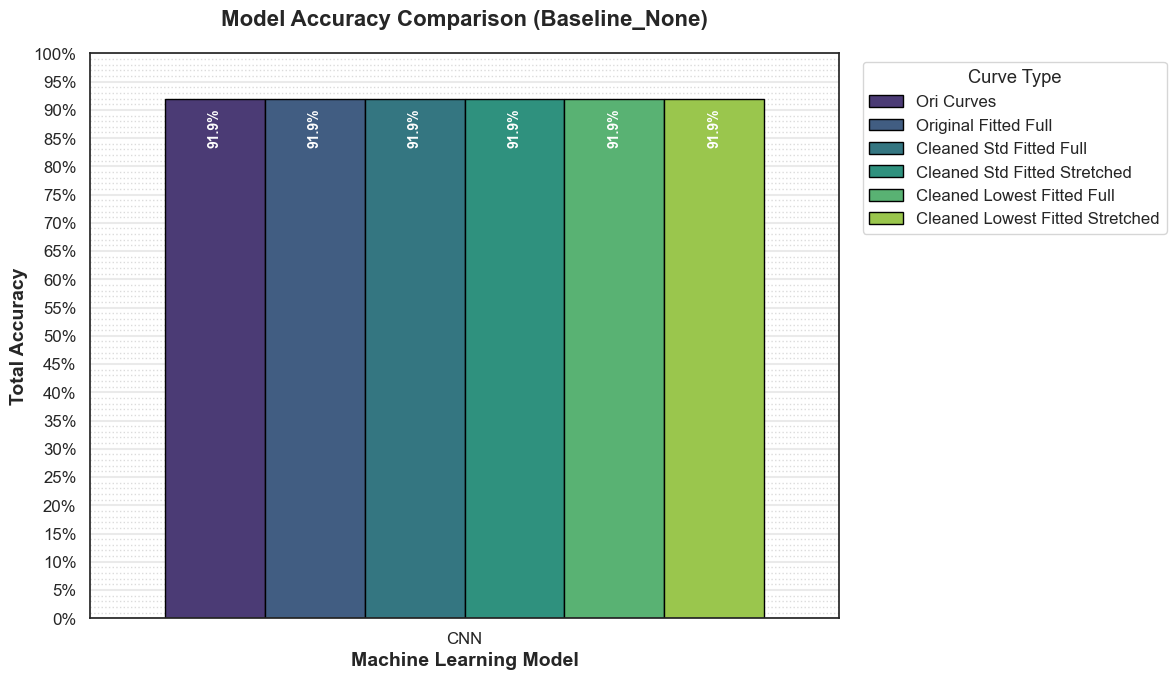

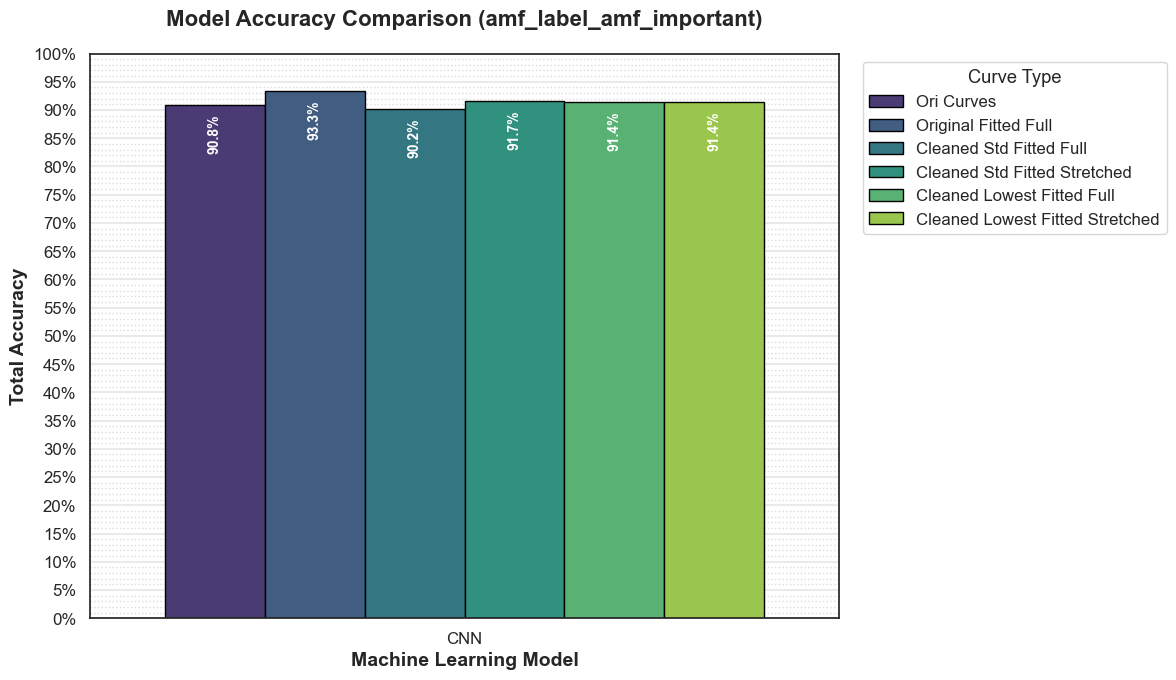

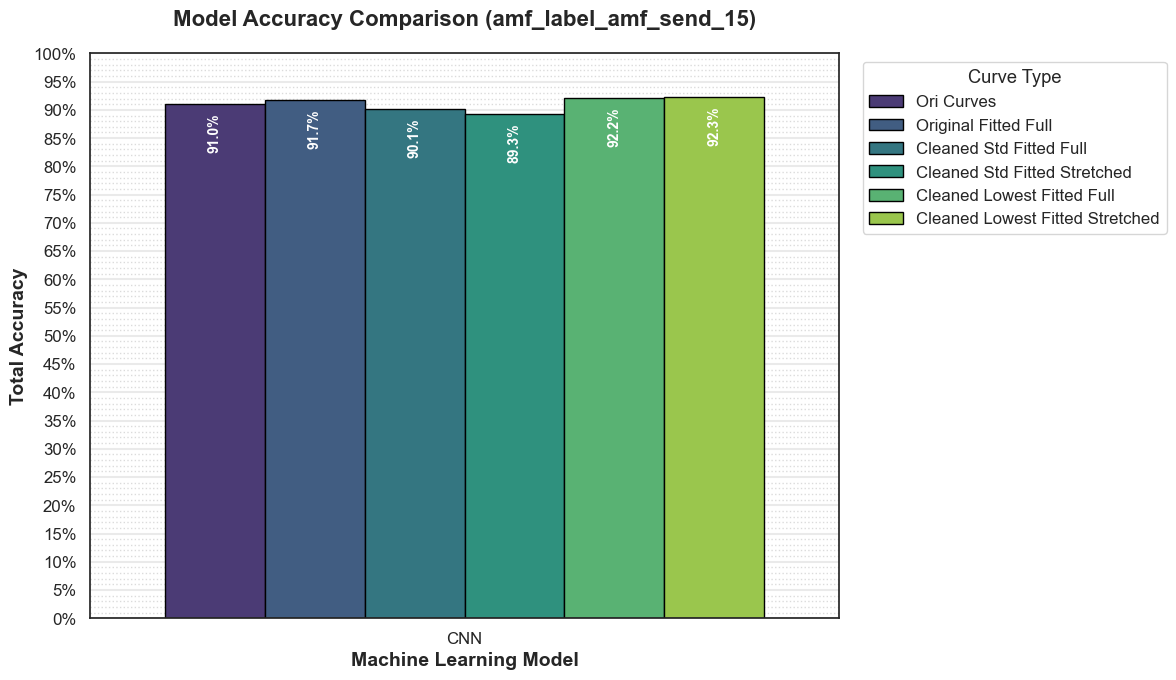

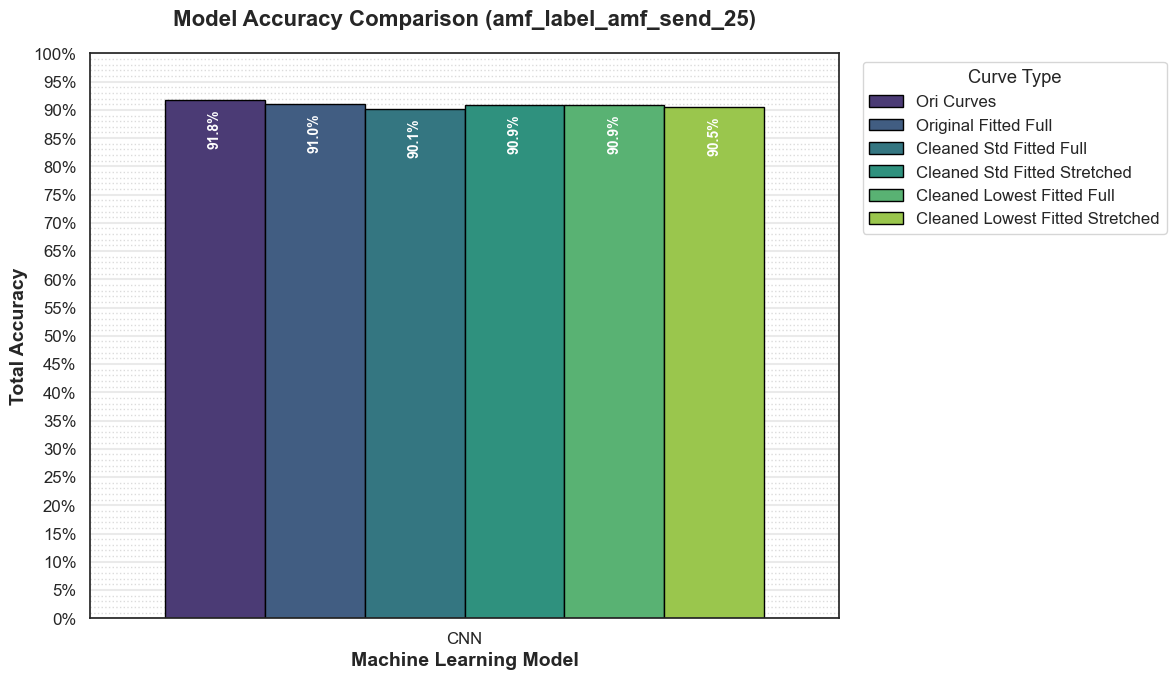

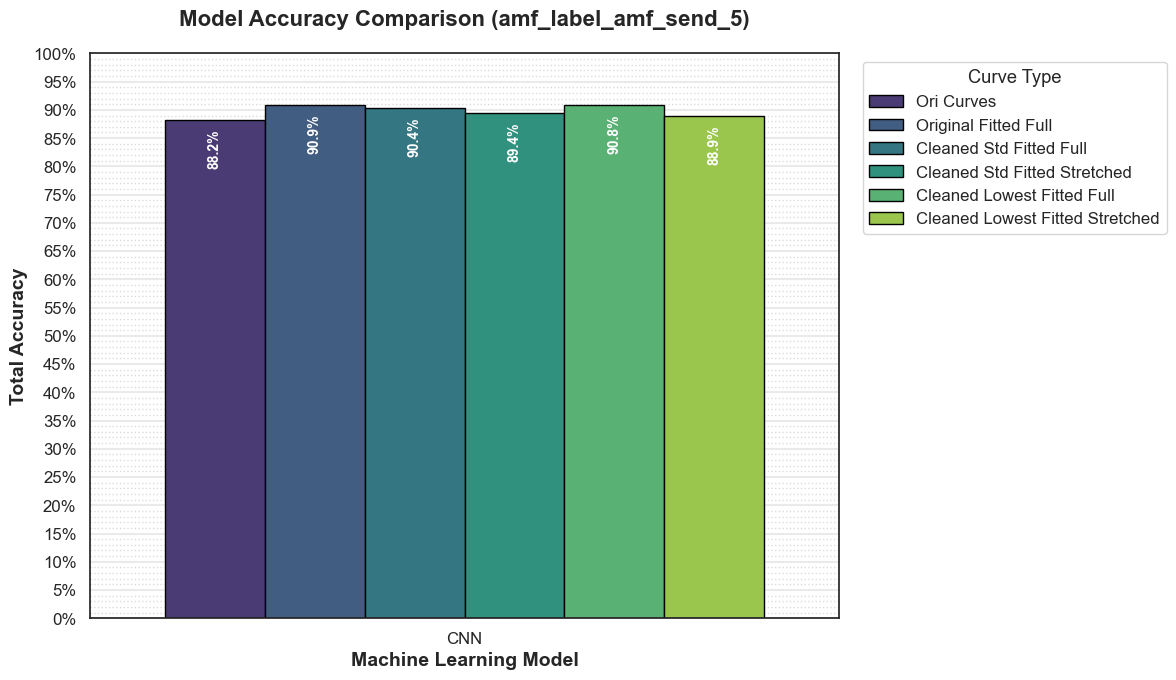

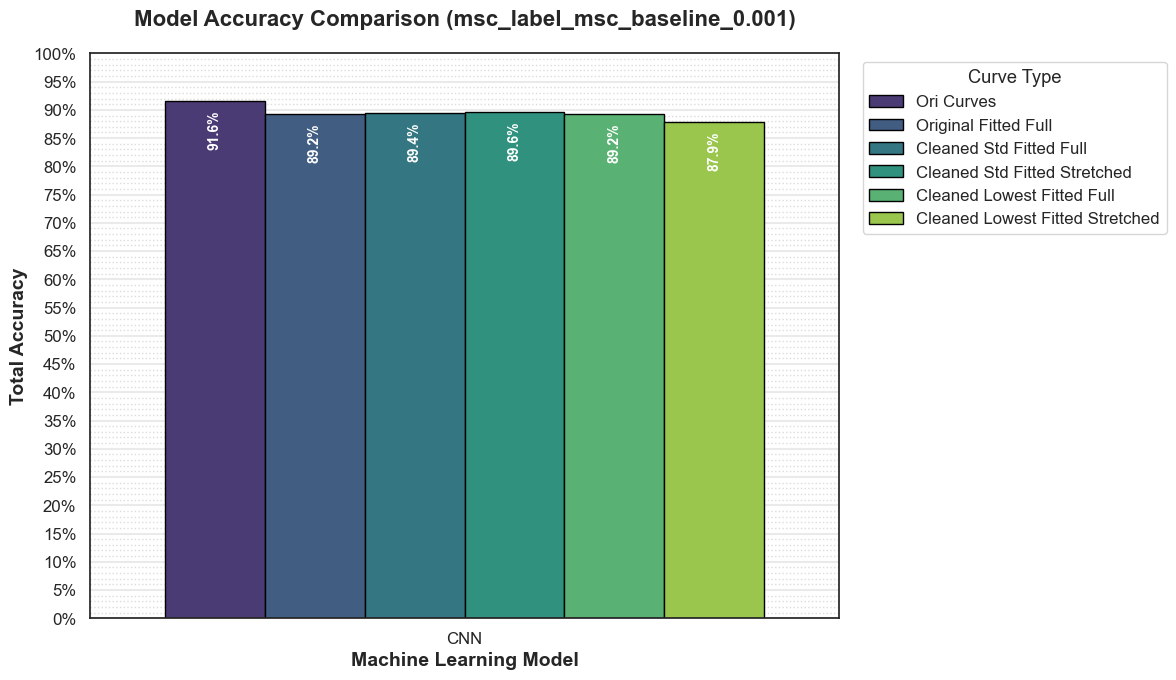

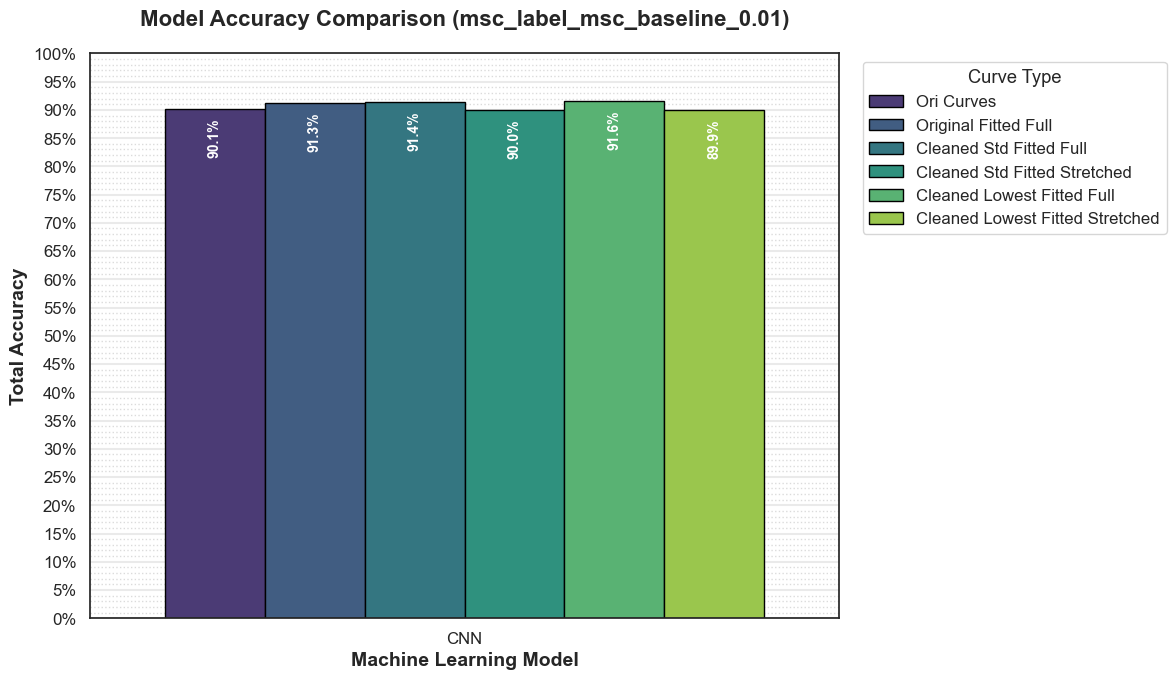

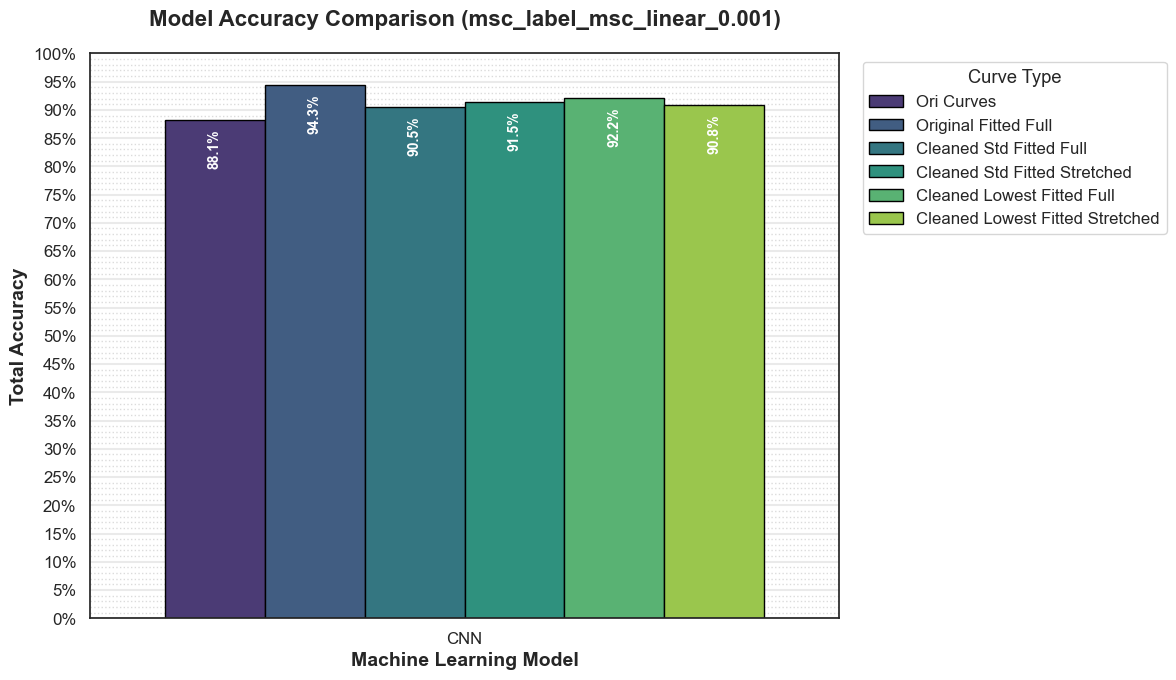

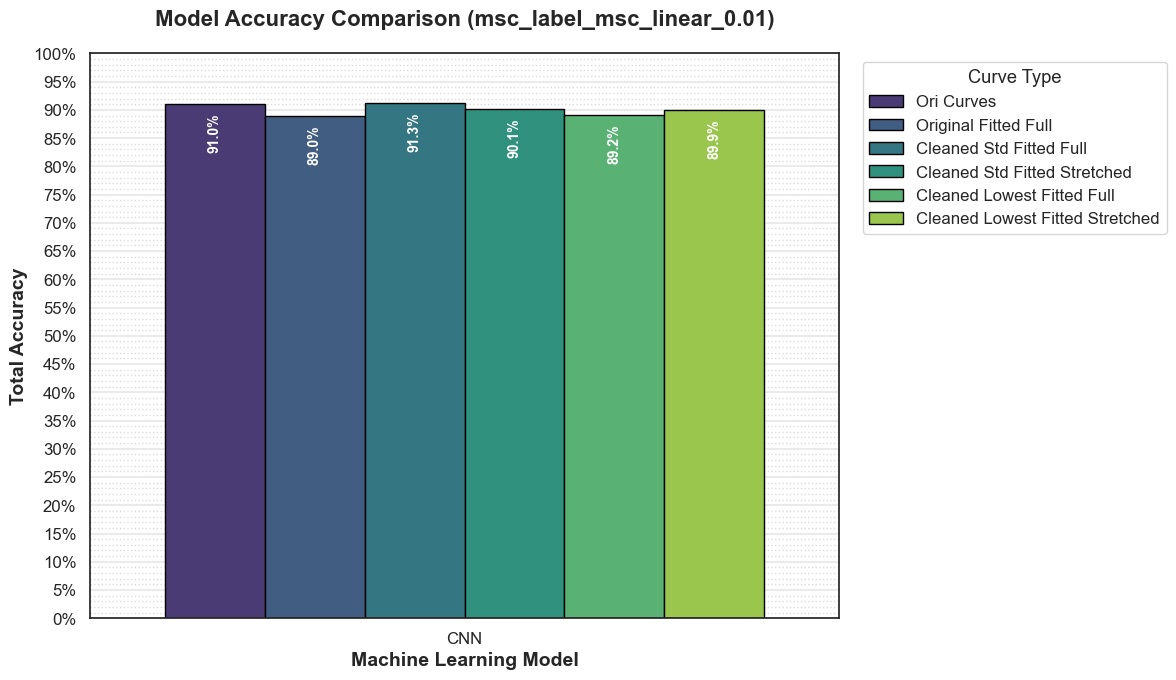

In [9]:
for filter in np.unique(result_df.outlier_filter.values):
# for filter in ["Baseline_None"]:
    sigfit_curves_compare = ["Ori Curves", "Original Fitted Full", "Cleaned Lowest Fitted Full", "Cleaned Lowest Fitted Stretched", "Cleaned Std Fitted Full", "Cleaned Std Fitted Stretched"]
    sigfit_training_compare = ["Reference"]
    sigfit_filter_compare = [filter]

    sigfit_compare_df = result_df[result_df["curve_name"].isin(sigfit_curves_compare) & result_df["training_mode"].isin(sigfit_training_compare) & result_df["outlier_filter"].isin(sigfit_filter_compare)]
    plot_accuracy_comparison_static(sigfit_compare_df, title=f"Model Accuracy Comparison ({filter})")

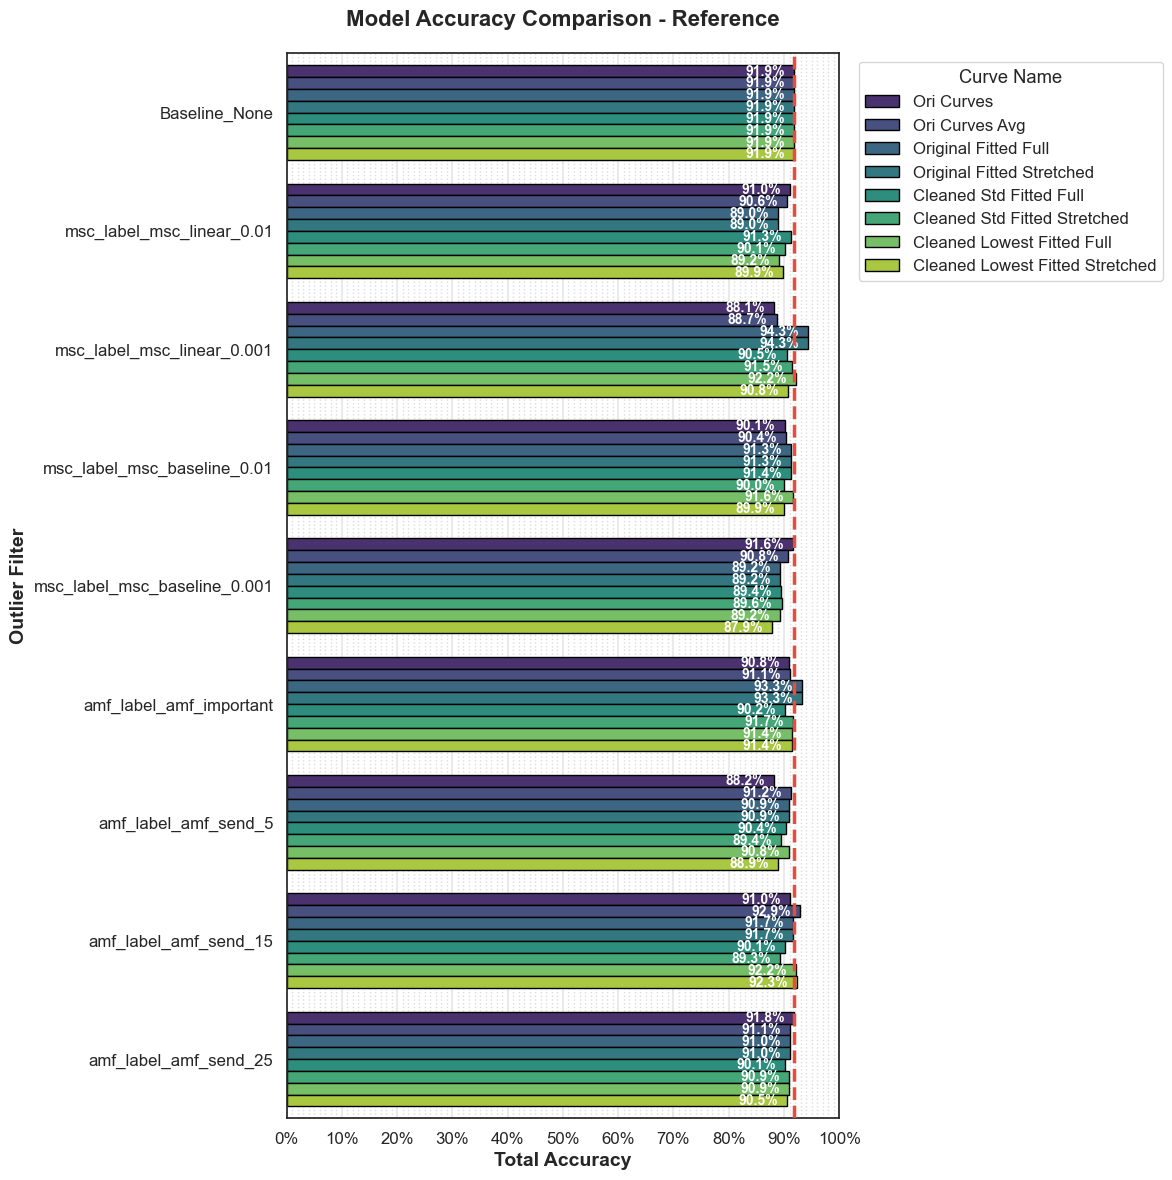

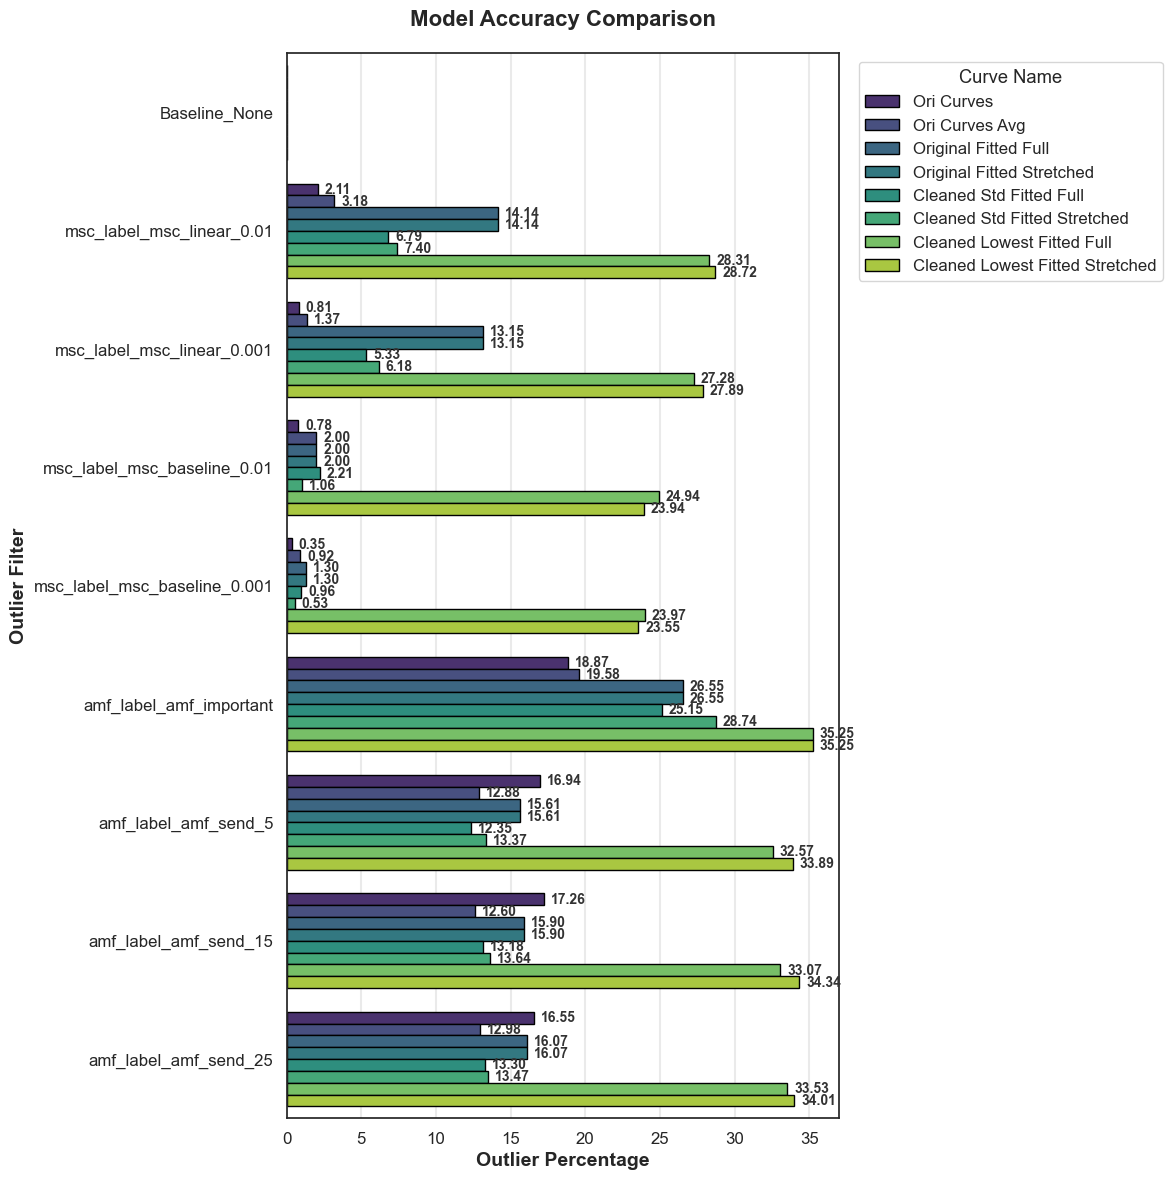

In [ ]:
# sigfit_curves_compare = ["Ori Curves", "Original Fitted Full", "Cleaned Lowest Fitted Full", "Cleaned Lowest Fitted Stretched", "Cleaned Std Fitted Full", "Cleaned Std Fitted Stretched"]
filtered_df_allmodes = result_df[(result_df["model"] == "CNN")]
filtered_df = filtered_df_allmodes[(filtered_df_allmodes["training_mode"] == "Reference")]
# filtered_df = result_df[(result_df["model"] == "CNN") & (result_df["training_mode"] == "Reference")]

plot_flexible_grouped_bar(
    df=filtered_df,
    x_col="outlier_filter",
    y_col="total_accuracy",
    hue_col="curve_name",
    title="Model Accuracy Comparison\n",
    is_percentage=True,
    is_horizontal=True,
    baseline_value= result_df[(result_df["curve_name"] == "Ori Curves") & (result_df["outlier_filter"] == "Baseline_None") & (result_df["training_mode"] == "Reference")  & (result_df["model"] == "CNN")].total_accuracy.values[0]
)

# filtered_df = filtered_df_allmodes[(filtered_df_allmodes["training_mode"] == "Native")]
# plot_flexible_grouped_bar(
#     df=filtered_df,
#     x_col="outlier_filter",
#     y_col="total_accuracy",
#     hue_col="curve_name",
#     title="Model Accuracy Comparison - Native",
#     is_percentage=True,
#     is_horizontal=True,
#     baseline_value= result_df[(result_df["curve_name"] == "Ori Curves") & (result_df["outlier_filter"] == "Baseline_None") & (result_df["training_mode"] == "Native")  & (result_df["model"] == "CNN")].total_accuracy.values[0]
# )

plot_flexible_grouped_bar(
    df=filtered_df,
    x_col="outlier_filter",
    y_col="outlier_percentage",
    hue_col="curve_name",
    title="Model Accuracy Comparison",
    is_percentage=False,
    is_horizontal=True,
)

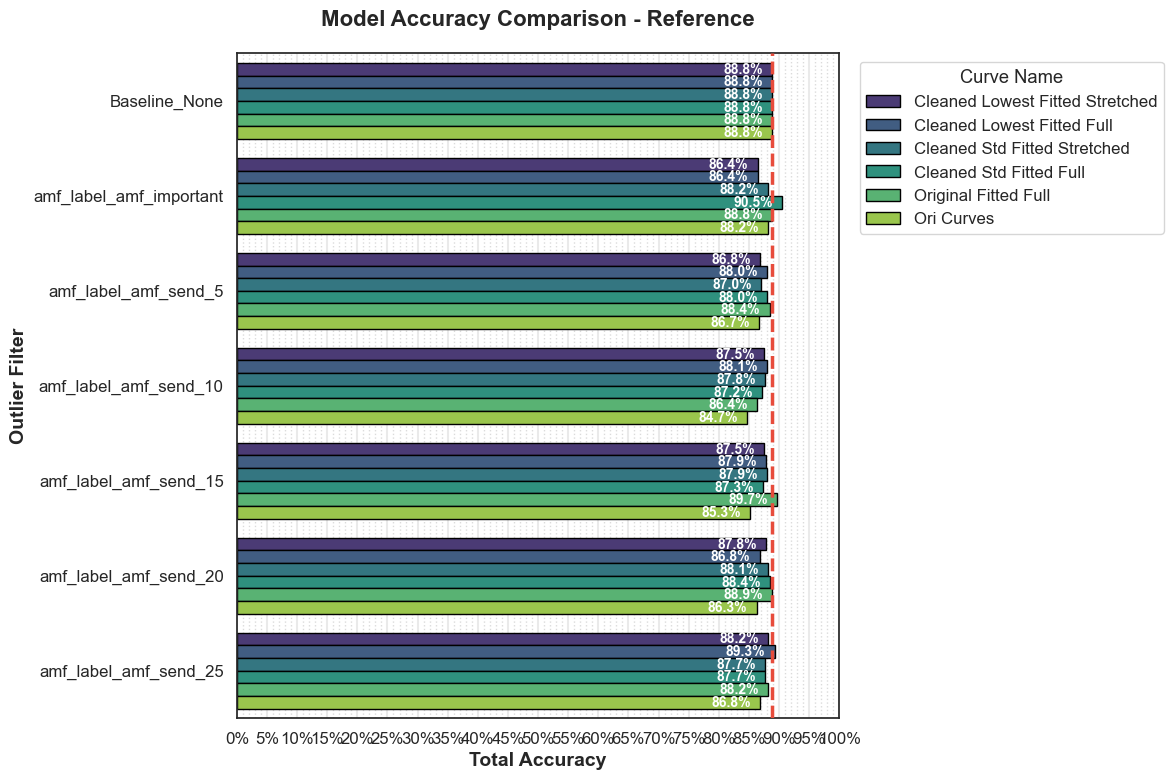

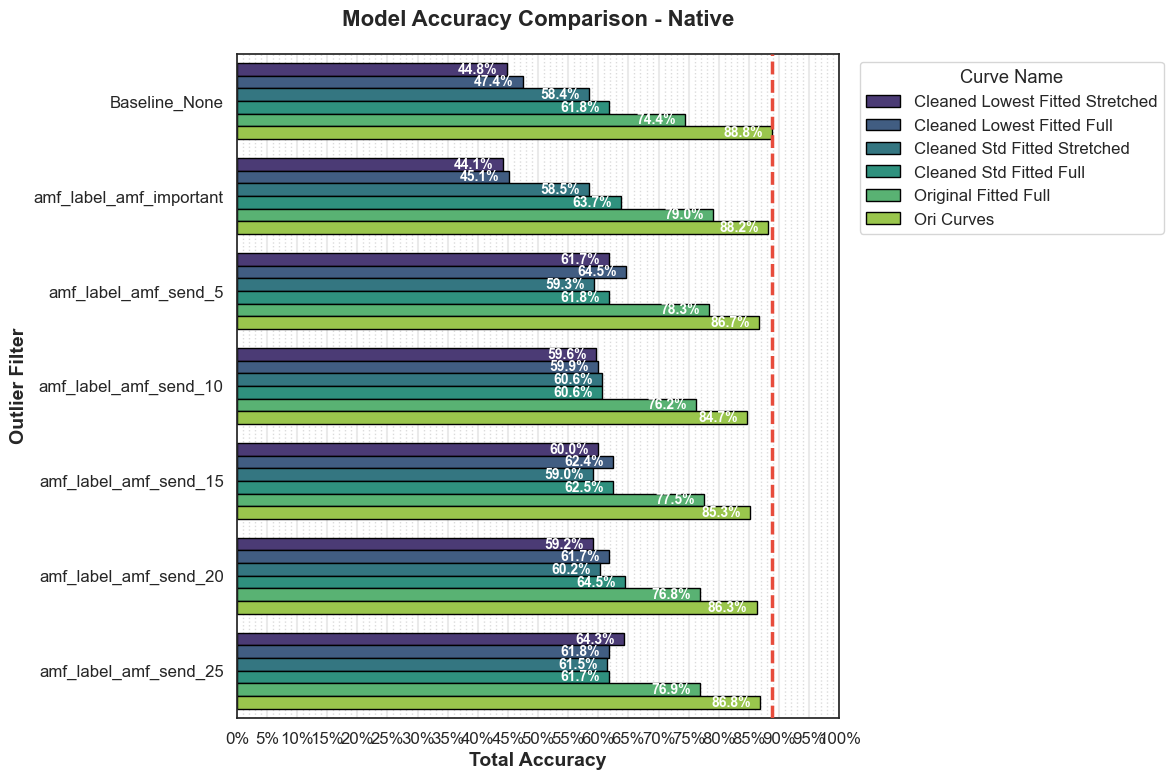

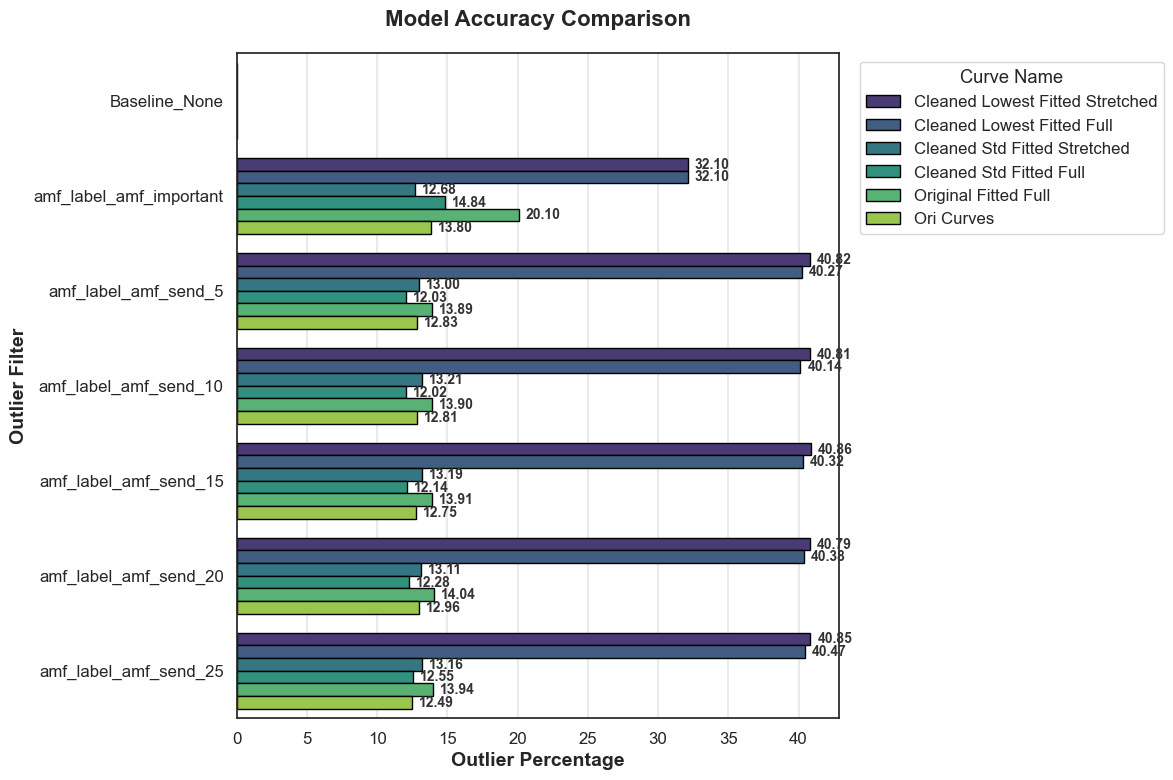

In [70]:
sigfit_curves_compare = ["Ori Curves", "Original Fitted Full", "Cleaned Lowest Fitted Full", "Cleaned Lowest Fitted Stretched", "Cleaned Std Fitted Full", "Cleaned Std Fitted Stretched"]
filtered_df_allmodes = result_df[(result_df["outlier_filter"].isin(['Baseline_None', 'amf_label_amf_important', 'amf_label_amf_send_10', 'amf_label_amf_send_15', 'amf_label_amf_send_20', 'amf_label_amf_send_25', 'amf_label_amf_send_5'])) & (result_df["model"] == "CNN") & result_df["curve_name"].isin(sigfit_curves_compare)]
filtered_df = filtered_df_allmodes[(filtered_df_allmodes["training_mode"] == "Reference")]
# filtered_df = result_df[(result_df["model"] == "CNN") & (result_df["training_mode"] == "Reference")]

plot_flexible_grouped_bar(
    df=filtered_df,
    x_col="outlier_filter",
    y_col="total_accuracy",
    hue_col="curve_name",
    title="Model Accuracy Comparison - Reference",
    is_percentage=True,
    is_horizontal=True,
    baseline_value= result_df[(result_df["curve_name"] == "Ori Curves") & (result_df["outlier_filter"] == "Baseline_None") & (result_df["training_mode"] == "Reference")  & (result_df["model"] == "CNN")].total_accuracy.values[0]
)

filtered_df = filtered_df_allmodes[(filtered_df_allmodes["training_mode"] == "Native")]
plot_flexible_grouped_bar(
    df=filtered_df,
    x_col="outlier_filter",
    y_col="total_accuracy",
    hue_col="curve_name",
    title="Model Accuracy Comparison - Native",
    is_percentage=True,
    is_horizontal=True,
    baseline_value= result_df[(result_df["curve_name"] == "Ori Curves") & (result_df["outlier_filter"] == "Baseline_None") & (result_df["training_mode"] == "Native")  & (result_df["model"] == "CNN")].total_accuracy.values[0]
)

plot_flexible_grouped_bar(
    df=filtered_df,
    x_col="outlier_filter",
    y_col="outlier_percentage",
    hue_col="curve_name",
    title="Model Accuracy Comparison",
    is_percentage=False,
    is_horizontal=True,
)

In [10]:
result_df.sort_values("total_accuracy", ascending=False).head(15)

,curve_name,training_mode,outlier_filter,model,outlier_percentage,total_accuracy,accuracy_well_0,accuracy_well_1,accuracy_well_2,accuracy_well_3,accuracy_well_4,accuracy_well_5,accuracy_well_6,accuracy_well_7,accuracy_well_8,accuracy_well_9,accuracy_well_avg
1629,Ori Curves Avg,Reference,mean_std_label_env_1std,CNN,65.52,0.930120,0.820513,0.920000,0.333333,0.981132,1.000000,0.848485,1.000000,1.000000,0.854167,0.978723,0.873635
1695,Ori Curves,Native,mean_std_label_env_2std,CNN,56.84,0.919231,0.897436,0.774194,0.857143,0.944444,0.961039,0.923077,1.000000,0.250000,0.900000,0.983333,0.849067
1758,Ori Curves,Reference,mean_std_label_env_2std,CNN,56.84,0.919231,0.897436,0.774194,0.857143,0.944444,0.961039,0.923077,1.000000,0.250000,0.900000,0.983333,0.849067
1251,Cleaned Std Fitted Full,Reference,mean_std_label_env_1std,CNN,48.15,0.918269,0.917808,0.816901,0.444444,0.955556,0.974684,0.916667,1.000000,0.142857,0.885714,0.960526,0.801516
369,Avg Cleaned Std Fitted Stretched,Reference,mean_std_label_env_1std,CNN,43.49,0.913235,0.881579,0.819277,0.250000,1.000000,0.945455,0.909091,1.000000,0.666667,0.866667,0.929577,0.826831
1630,Ori Curves Avg,Reference,mean_std_label_env_1std,KNN,65.52,0.908434,0.923077,0.760000,0.333333,1.000000,1.000000,0.878788,1.000000,0.333333,0.854167,0.914894,0.799759
1567,Ori Curves Avg,Native,mean_std_label_env_1std,KNN,65.52,0.908434,0.923077,0.780000,0.333333,1.000000,1.000000,0.848485,1.000000,0.166667,0.875000,0.914894,0.784146
747,Avg Fitted Full,Reference,mean_std_label_env_1std,CNN,45.73,0.908116,0.887324,0.802469,0.444444,0.901235,0.915789,0.921569,1.000000,0.444444,0.972603,0.950617,0.824049
621,Avg Fitted Stretched,Reference,mean_std_label_env_1std,CNN,45.73,0.908116,0.887324,0.802469,0.444444,0.901235,0.915789,0.921569,1.000000,0.444444,0.972603,0.950617,0.824049
1218,Cleaned Std Fitted Full,Reference,amf_label_amf_important,CNN,14.84,0.905366,0.833333,0.837037,0.272727,0.916667,0.993289,0.879121,0.993827,0.307692,0.851240,0.982609,0.786754


In [77]:
result_df[(result_df["curve_name"] == "Ori Curves") & (result_df["outlier_filter"] == "Baseline_None") & (result_df["training_mode"] == "Native")  & (result_df["model"] == "CNN")].filter(like="accuracy").T

,1638
total_accuracy,0.887874
accuracy_well_0,0.719512
accuracy_well_1,0.800000
accuracy_well_2,0.071429
accuracy_well_3,0.942857
accuracy_well_4,0.982659
accuracy_well_5,0.834862
accuracy_well_6,0.978495
accuracy_well_7,0.235294
accuracy_well_8,0.928058


In [79]:
result_df.sort_values("total_accuracy", ascending=False).head(15)

,curve_name,training_mode,outlier_filter,model,outlier_percentage,total_accuracy,accuracy_well_0,accuracy_well_1,accuracy_well_2,accuracy_well_3,accuracy_well_4,accuracy_well_5,accuracy_well_6,accuracy_well_7,accuracy_well_8,accuracy_well_9,accuracy_well_avg
1629,Ori Curves Avg,Reference,mean_std_label_env_1std,CNN,65.52,0.930120,0.820513,0.920000,0.333333,0.981132,1.000000,0.848485,1.000000,1.000000,0.854167,0.978723,0.873635
1695,Ori Curves,Native,mean_std_label_env_2std,CNN,56.84,0.919231,0.897436,0.774194,0.857143,0.944444,0.961039,0.923077,1.000000,0.250000,0.900000,0.983333,0.849067
1758,Ori Curves,Reference,mean_std_label_env_2std,CNN,56.84,0.919231,0.897436,0.774194,0.857143,0.944444,0.961039,0.923077,1.000000,0.250000,0.900000,0.983333,0.849067
1251,Cleaned Std Fitted Full,Reference,mean_std_label_env_1std,CNN,48.15,0.918269,0.917808,0.816901,0.444444,0.955556,0.974684,0.916667,1.000000,0.142857,0.885714,0.960526,0.801516
369,Avg Cleaned Std Fitted Stretched,Reference,mean_std_label_env_1std,CNN,43.49,0.913235,0.881579,0.819277,0.250000,1.000000,0.945455,0.909091,1.000000,0.666667,0.866667,0.929577,0.826831
1630,Ori Curves Avg,Reference,mean_std_label_env_1std,KNN,65.52,0.908434,0.923077,0.760000,0.333333,1.000000,1.000000,0.878788,1.000000,0.333333,0.854167,0.914894,0.799759
1567,Ori Curves Avg,Native,mean_std_label_env_1std,KNN,65.52,0.908434,0.923077,0.780000,0.333333,1.000000,1.000000,0.848485,1.000000,0.166667,0.875000,0.914894,0.784146
747,Avg Fitted Full,Reference,mean_std_label_env_1std,CNN,45.73,0.908116,0.887324,0.802469,0.444444,0.901235,0.915789,0.921569,1.000000,0.444444,0.972603,0.950617,0.824049
621,Avg Fitted Stretched,Reference,mean_std_label_env_1std,CNN,45.73,0.908116,0.887324,0.802469,0.444444,0.901235,0.915789,0.921569,1.000000,0.444444,0.972603,0.950617,0.824049
1218,Cleaned Std Fitted Full,Reference,amf_label_amf_important,CNN,14.84,0.905366,0.833333,0.837037,0.272727,0.916667,0.993289,0.879121,0.993827,0.307692,0.851240,0.982609,0.786754


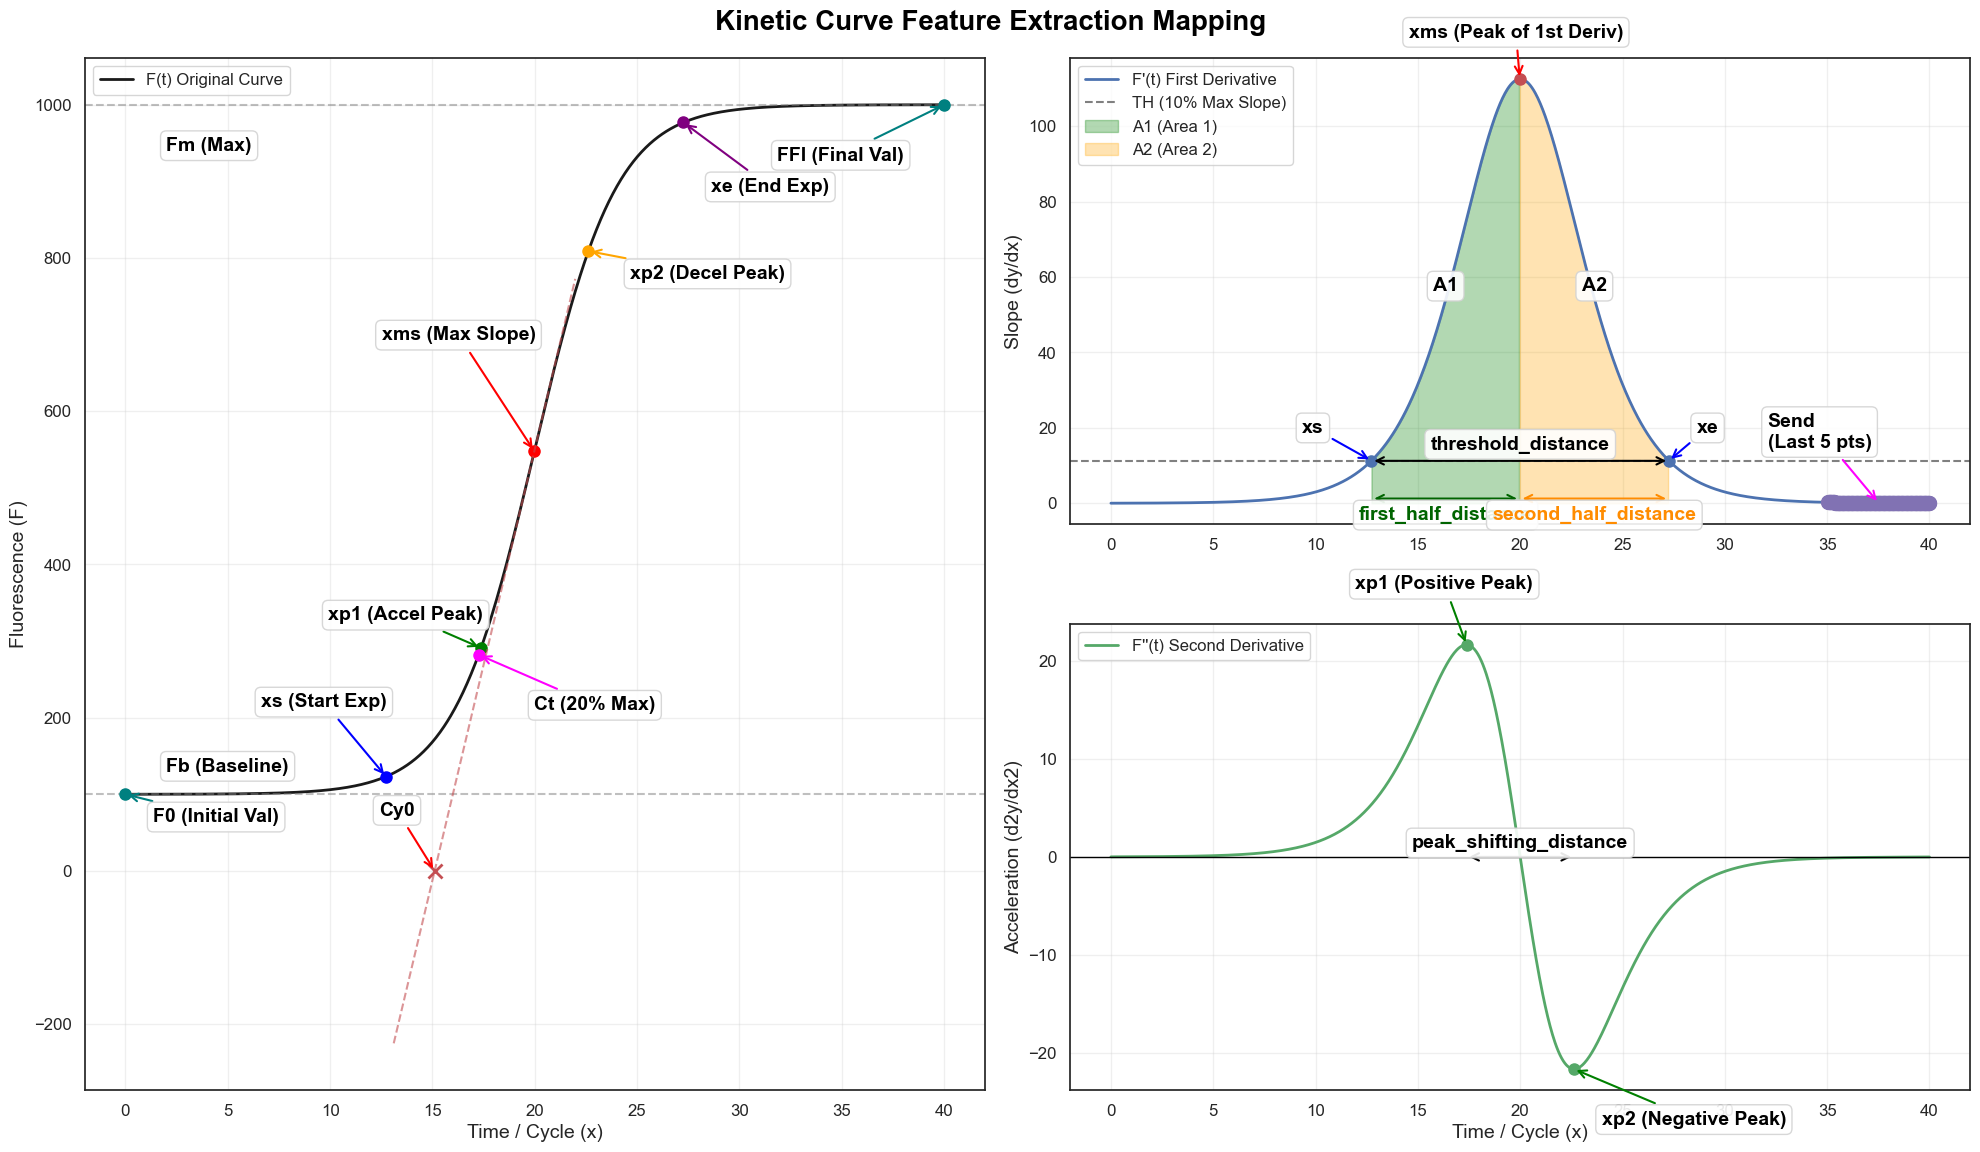

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Generate smoothed mock sigmoid data
x = np.linspace(0, 40, 1000)
Fb, Fm, Sc, Cs = 100, 1000, 0.5, 20
y = Fb + (Fm - Fb) / (1 + np.exp(-Sc * (x - Cs))) 

# First and second derivatives
dy = np.gradient(y, x)
d2y = np.gradient(dy, x)

# Calculate original features
xms_idx = np.argmax(dy)
xms = x[xms_idx]
TH = 0.1 * dy[xms_idx]
above_th = np.where(dy > TH)[0]
xs_idx, xe_idx = above_th[0], above_th[-1]
xs, xe = x[xs_idx], x[xe_idx]
xp1_idx = np.argmax(d2y)
xp2_idx = np.argmin(d2y)
xp1, xp2 = x[xp1_idx], x[xp2_idx]
Ct_target = Fb + 0.2 * (Fm - Fb)
Ct_idx = np.where(y >= Ct_target)[0][0]
Ct = x[Ct_idx]
Cy0 = xms - (y[xms_idx] / dy[xms_idx])

# Initialize the plot with GridSpec for a 2x2 layout
fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Assign subplots to grid positions
ax1 = fig.add_subplot(gs[:, 0])             # Col 0, spans both rows
ax2 = fig.add_subplot(gs[0, 1], sharex=ax1) # Col 1, row 0
ax3 = fig.add_subplot(gs[1, 1], sharex=ax1) # Col 1, row 1

fig.suptitle('Kinetic Curve Feature Extraction Mapping', fontsize=20, fontweight='bold', color='black', y=0.96)

annotation_size = 14

# Uniform styling for ALL text
TEXT_PROP = dict(color='black', fontweight='bold', fontsize=annotation_size, 
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="lightgray", alpha=0.9))

# ==========================================
# SUBPLOT 1: Original Curve
# ==========================================
ax1.plot(x, y, 'k-', lw=2, label='F(t) Original Curve')
ax1.set_ylabel('Fluorescence (F)', fontsize=14)
ax1.set_xlabel('Time / Cycle (x)', fontsize=14)
ax1.grid(True, alpha=0.3)

ax1.axhline(Fb, color='gray', linestyle='--', alpha=0.5)
ax1.text(2, Fb + 30, 'Fb (Baseline)', **TEXT_PROP)
ax1.axhline(Fm, color='gray', linestyle='--', alpha=0.5)
ax1.text(2, Fm - 60, 'Fm (Max)', **TEXT_PROP)

# Define precise xytext offsets to guarantee NO overlapping text
points = [
    (xs, y[xs_idx], 'xs (Start Exp)', 'blue', (-90, 50)),
    (xe, y[xe_idx], 'xe (End Exp)', 'purple', (20, -50)),
    (xms, y[xms_idx], 'xms (Max Slope)', 'red', (-110, 80)),
    (xp1, y[xp1_idx], 'xp1 (Accel Peak)', 'green', (-110, 20)),
    (xp2, y[xp2_idx], 'xp2 (Decel Peak)', 'orange', (30, -20)),
    (Ct, y[Ct_idx], 'Ct (20% Max)', 'magenta', (40, -40)),
    (x[0], y[0], 'F0 (Initial Val)', 'teal', (20, -20)),
    (x[-1], y[-1], 'FFI (Final Val)', 'teal', (-120, -40))
]

for px, py, label, color, offset in points:
    ax1.plot(px, py, marker='o', markersize=8, color=color)
    ax1.annotate(label, (px, py), xytext=offset, textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color=color, lw=1.5), **TEXT_PROP)

# Cy0 Tangent Line
tangent_x = np.linspace(Cy0 - 2, xms + 2, 100)
tangent_y = dy[xms_idx] * (tangent_x - xms) + y[xms_idx]
ax1.plot(tangent_x, tangent_y, 'r--', alpha=0.6)
ax1.plot(Cy0, 0, 'rx', markersize=10, markeredgewidth=2)
ax1.annotate('Cy0', (Cy0, 0), xytext=(-40, 40), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5), **TEXT_PROP)
ax1.legend(loc='upper left', fontsize=12)


# ==========================================
# SUBPLOT 2: First Derivative
# ==========================================
ax2.plot(x, dy, 'b-', lw=2, label="F'(t) First Derivative")
ax2.set_ylabel('Slope (dy/dx)', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.axhline(TH, color='gray', linestyle='--', label='TH (10% Max Slope)')

# Critical points on 1st Deriv
ax2.plot(xms, dy[xms_idx], 'ro', markersize=8)
ax2.annotate('xms (Peak of 1st Deriv)', (xms, dy[xms_idx]), xytext=(-80, 30), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5), **TEXT_PROP)

ax2.plot([xs, xe], [dy[xs_idx], dy[xe_idx]], 'bo', markersize=8)
ax2.annotate('xs', (xs, dy[xs_idx]), xytext=(-50, 20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='blue', lw=1.5), **TEXT_PROP)
ax2.annotate('xe', (xe, dy[xe_idx]), xytext=(20, 20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='blue', lw=1.5), **TEXT_PROP)

# Area Shading
ax2.fill_between(x[xs_idx:xms_idx], dy[xs_idx:xms_idx], alpha=0.3, color='green', label='A1 (Area 1)')
ax2.fill_between(x[xms_idx:xe_idx], dy[xms_idx:xe_idx], alpha=0.3, color='orange', label='A2 (Area 2)')
ax2.text((xs+xms)/2, dy[xms_idx]/2, 'A1', ha='center', **TEXT_PROP)
ax2.text((xms+xe)/2, dy[xms_idx]/2, 'A2', ha='center', **TEXT_PROP)

# Send (Highlight last 5 points of the derivative)
ax2.plot(x[x>35], dy[x>35], 'mo', markersize=10)
ax2.annotate('Send\n(Last 5 pts)', (x[int(len(x)/40*37.5)], dy[int(len(x)/40*37.5)]), xytext=(-80, 40), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='magenta', lw=1.5), **TEXT_PROP)

# Distances
ax2.annotate('', xy=(xs, TH), xytext=(xe, TH), arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax2.text((xs+xe)/2, TH + 2, 'threshold_distance', ha='center', va='bottom', **TEXT_PROP)

ax2.annotate('', xy=(xs, TH - 10), xytext=(xms, TH - 10), arrowprops=dict(arrowstyle='<->', color='darkgreen', lw=1.5))
ax2.text((xs+xms)/2, TH - 12, 'first_half_distance', ha='center', va='top', **{**TEXT_PROP, 'color': 'darkgreen'})

ax2.annotate('', xy=(xms, TH - 10), xytext=(xe, TH - 10), arrowprops=dict(arrowstyle='<->', color='darkorange', lw=1.5))
ax2.text((xms+xe)/2, TH - 12, 'second_half_distance', ha='center', va='top', **{**TEXT_PROP, 'color': 'darkorange'})

ax2.legend(loc='upper left', fontsize=12)


# ==========================================
# SUBPLOT 3: Second Derivative
# ==========================================
ax3.plot(x, d2y, 'g-', lw=2, label="F''(t) Second Derivative")
ax3.set_ylabel('Acceleration (d2y/dx2)', fontsize=14)
ax3.set_xlabel('Time / Cycle (x)', fontsize=14)
ax3.grid(True, alpha=0.3)
ax3.axhline(0, color='black', lw=1)

ax3.plot(xp1, d2y[xp1_idx], 'go', markersize=8)
ax3.annotate('xp1 (Positive Peak)', (xp1, d2y[xp1_idx]), xytext=(-80, 40), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5), **TEXT_PROP)

ax3.plot(xp2, d2y[xp2_idx], 'go', markersize=8)
ax3.annotate('xp2 (Negative Peak)', (xp2, d2y[xp2_idx]), xytext=(20, -40), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5), **TEXT_PROP)

ax3.annotate('', xy=(xp1, 0), xytext=(xp2, 0), arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax3.text((xp1+xp2)/2, 0.5, 'peak_shifting_distance', ha='center', va='bottom', **TEXT_PROP)

ax3.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Leave space for the main title
plt.show()

In [84]:
import os
import pickle
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import roc_curve, auc

# ==========================================
# 1. LOAD THE DICTIONARY DATA
# ==========================================
exp_path = "/Users/kautsarg/Documents/Final Project/Run Data/trial test data/D20250808_E00_C00_F4500KHz_U_Sample_7"
data_path = os.path.join(exp_path, "classification_performances_with_proba.pkl")

with open(data_path, 'rb') as f:
    result_data = pickle.load(f)

# Robust Loading Strategy
if isinstance(result_data, dict):
    all_ml_results = result_data
else:
    raise TypeError(f"Expected a nested dictionary from training, got {type(result_data)}")

# Map model keys to their stored probabilities
model_mappings = {
    'CNN (ACA)': ('classes_AC_', 'y_probs_AC_'),
    'KNN (ACA)': ('classes_AC_kNN_', 'y_probs_AC_kNN_'),
    'LR (FFI)':  ('classes_FFI_', 'y_probs_FFI_')
}

# Helper to calculate Macro-Average ROC for multiclass
def compute_macro_roc(y_true, y_prob, classes):
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []
    for i, c in enumerate(classes):
        y_true_bin = (y_true == c).astype(int)
        fpr, tpr, _ = roc_curve(y_true_bin, y_prob[:, i])
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
    
    if len(tprs) == 0:
        return mean_fpr, np.zeros_like(mean_fpr), 0.0
        
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    macro_auc = auc(mean_fpr, mean_tpr)
    return mean_fpr, mean_tpr, macro_auc


# ==========================================
# 2. PLOT 1: GLOBAL MACRO-ROC (Separated by Model)
# ==========================================
def generate_global_roc(results_dict, save_path):
    models = list(model_mappings.keys())
    
    # 1 Row, 3 Columns (One for each model)
    fig = make_subplots(
        rows=1, cols=3, 
        subplot_titles=models,
        horizontal_spacing=0.08
    )
    
    dropdown_keys = []
    trace_visibility = {} 
    current_trace_idx = 0
    
    colors = go.Figure().layout.template.layout.colorway 
    
    for dataset_name, modes in results_dict.items():
        for mode_name, filters in modes.items():
            dropdown_key = f"{dataset_name} | {mode_name}"
            dropdown_keys.append(dropdown_key)
            trace_visibility[dropdown_key] = []
            
            for f_idx, (filter_name, metrics) in enumerate(filters.items()):
                filt_str = str(filter_name) if filter_name is not None else "Baseline (None)"
                y_true = metrics['y_trues_'][0] 
                
                # Assign a consistent color to the filter across all 3 subplots
                color = colors[f_idx % len(colors)]
                
                for model_idx, model_name in enumerate(models):
                    class_key, prob_key = model_mappings[model_name]
                    
                    if prob_key not in metrics or len(metrics[prob_key]) == 0:
                        continue
                        
                    y_prob = metrics[prob_key][0]
                    classes = metrics[class_key][0]
                    
                    fpr, tpr, roc_auc = compute_macro_roc(y_true, y_prob, classes)
                    
                    col = model_idx + 1
                    
                    fig.add_trace(go.Scatter(
                        x=fpr, y=tpr, mode='lines',
                        name=f"{filt_str[:30]}",
                        legendgroup=filt_str,          # Links the filter in the legend
                        showlegend=(model_idx == 0),   # Only show legend item once
                        line=dict(color=color),
                        visible=(dropdown_key == dropdown_keys[0]), 
                        hovertemplate=f"AUC: {roc_auc:.3f}<br>FPR: %{{x:.3f}}<br>TPR: %{{y:.3f}}<extra></extra>"
                    ), row=1, col=col)
                    
                    trace_visibility[dropdown_key].append(current_trace_idx)
                    current_trace_idx += 1

    # Add Random Guess Lines
    random_line_indices = []
    for col in range(1, 4):
        fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash', color='gray'), showlegend=False, visible=True), row=1, col=col)
        random_line_indices.append(current_trace_idx)
        current_trace_idx += 1
    
    # Build Dropdown Buttons
    buttons = []
    for key in dropdown_keys:
        vis_array = [False] * current_trace_idx
        for idx in trace_visibility[key]: vis_array[idx] = True
        for idx in random_line_indices: vis_array[idx] = True
        buttons.append(dict(label=key, method="update", args=[{"visible": vis_array}, {"title": f"Global Macro-ROC | {key}"}]))

    fig.update_layout(
        title=f"Global Macro-ROC | {dropdown_keys[0]}",
        width=1500, height=600, plot_bgcolor='white', hovermode="closest",
        updatemenus=[dict(active=0, buttons=buttons, x=0.0, y=1.2, xanchor="left", yanchor="top")],
        legend=dict(yanchor="top", y=1, xanchor="left", x=1.02)
    )
    
    # Lock aspect ratio to 1:1 for all 3 subplots
    for col in range(1, 4):
        fig.update_xaxes(title_text="FPR", showline=True, linewidth=1, linecolor='black', gridcolor='#eaeaea', row=1, col=col)
        fig.update_yaxes(title_text="TPR", scaleanchor=f"x{col}", scaleratio=1, showline=True, linewidth=1, linecolor='black', gridcolor='#eaeaea', row=1, col=col)
    
    fig.write_html(save_path)
    print(f"[*] Saved Global ROC (Separated by Model) to {save_path}")


# ==========================================
# 3. PLOT 2: WELL-WISE ROC (1 Plot, Lines = Wells)
# ==========================================
def generate_well_wise_roc(results_dict, save_path):
    # Find all unique classes/wells
    all_classes = set()
    for ds in results_dict.values():
        for md in ds.values():
            for flt in md.values():
                all_classes.update(flt['y_trues_'][0])
    all_classes = sorted(list(all_classes))
    
    # 1 Single Plot
    fig = go.Figure()
    
    dropdown_keys = []
    trace_visibility = {}
    current_trace_idx = 0
    
    colors = go.Figure().layout.template.layout.colorway 
    
    for dataset_name, modes in results_dict.items():
        for mode_name, filters in modes.items():
            for filter_name, metrics in filters.items():
                filt_str = str(filter_name) if filter_name is not None else "Baseline (None)"
                y_true = metrics['y_trues_'][0]
                
                for model_name, (class_key, prob_key) in model_mappings.items():
                    if prob_key not in metrics or len(metrics[prob_key]) == 0:
                        continue
                    
                    # New Dropdown Granularity: Dataset + Mode + Model + Filter
                    dropdown_key = f"{dataset_name} | {mode_name} | {model_name} | {filt_str}"
                    dropdown_keys.append(dropdown_key)
                    trace_visibility[dropdown_key] = []
                        
                    y_prob = metrics[prob_key][0]
                    classes = metrics[class_key][0]
                    
                    # Plot a curve for EACH well on the single plot
                    for i, c in enumerate(all_classes):
                        if c not in classes: continue
                            
                        class_idx = np.where(classes == c)[0][0]
                        y_true_bin = (y_true == c).astype(int)
                        
                        if len(np.unique(y_true_bin)) < 2: continue
                            
                        fpr, tpr, _ = roc_curve(y_true_bin, y_prob[:, class_idx])
                        roc_auc = auc(fpr, tpr)
                        
                        fig.add_trace(go.Scatter(
                            x=fpr, y=tpr, mode='lines',
                            name=f"Well {c} (AUC={roc_auc:.3f})",
                            line=dict(color=colors[i % len(colors)]),
                            visible=(dropdown_key == dropdown_keys[0]),
                            hovertemplate=f"<b>Well {c}</b><br>AUC: {roc_auc:.3f}<br>FPR: %{{x:.3f}}<br>TPR: %{{y:.3f}}<extra></extra>"
                        ))
                        
                        trace_visibility[dropdown_key].append(current_trace_idx)
                        current_trace_idx += 1

    # Add Random Guess Line
    fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash', color='gray'), name="Random Guess", visible=True))
    random_line_idx = current_trace_idx

    # Build Dropdown Buttons
    buttons = []
    for key in dropdown_keys:
        vis_array = [False] * (current_trace_idx + 1)
        for idx in trace_visibility[key]: vis_array[idx] = True
        vis_array[random_line_idx] = True 
            
        buttons.append(dict(label=key, method="update", args=[{"visible": vis_array}, {"title": f"Well-Wise ROC | {key}"}]))

    fig.update_layout(
        title=f"Well-Wise ROC | {dropdown_keys[0]}",
        xaxis_title="False Positive Rate (FPR)", yaxis_title="True Positive Rate (TPR)",
        yaxis=dict(scaleanchor="x", scaleratio=1), xaxis=dict(constrain='domain'),
        height=800, width=900, plot_bgcolor='white', hovermode="closest",
        updatemenus=[dict(active=0, buttons=buttons, x=0.0, y=1.1, xanchor="left", yanchor="top")],
        legend=dict(yanchor="top", y=1, xanchor="left", x=1.02)
    )
    
    fig.update_xaxes(showline=True, linewidth=1, linecolor='black', gridcolor='#eaeaea')
    fig.update_yaxes(showline=True, linewidth=1, linecolor='black', gridcolor='#eaeaea')

    fig.write_html(save_path)
    print(f"[*] Saved Well-wise ROC (1 Plot, Lines = Wells) to {save_path}")

# ==========================================
# 4. EXECUTE
# ==========================================
global_html_path = os.path.join(exp_path, "global_roc_auc_combinations.html")
well_wise_html_path = os.path.join(exp_path, "well_wise_roc_auc_combinations.html")

print("Generating plots... This may take a moment due to the large number of combinations.")
generate_global_roc(all_ml_results, global_html_path)
generate_well_wise_roc(all_ml_results, well_wise_html_path)
print("Done!")

Generating plots... This may take a moment due to the large number of combinations.
[*] Saved Global ROC (Separated by Model) to /Users/kautsarg/Documents/Final Project/Run Data/trial test data/D20250808_E00_C00_F4500KHz_U_Sample_7/global_roc_auc_combinations.html
[*] Saved Well-wise ROC (1 Plot, Lines = Wells) to /Users/kautsarg/Documents/Final Project/Run Data/trial test data/D20250808_E00_C00_F4500KHz_U_Sample_7/well_wise_roc_auc_combinations.html
Done!


In [48]:
from scipy.stats import chi2

def plot_chi_square(df, p_value=0.05):
    """
    Plots the Chi-Square distribution for a given degree of freedom
    and draws a vertical line at the threshold for the given p-value.
    
    Parameters:
    df (int): Degrees of freedom
    p_value (float): Significance level for the threshold (e.g., 0.05, 0.01, 0.001)
    """
    x_min = 0
    x_max = 10000
    x = np.linspace(x_min, x_max, 500)
    
    # 2. Calculate the PDF
    y = chi2.pdf(x, df)
    
    # 3. Calculate the critical threshold value for the given p-value
    threshold = chi2.ppf(1 - p_value, df)
    
    # --- PLOTTING ---
    plt.figure(figsize=(10, 2))
    
    # Draw the main distribution curve
    plt.plot(x, y, label=f'df = {df}', linewidth=2.5, color='#2980b9')
    
    # Draw the vertical threshold line
    plt.axvline(x=threshold, color='#e74c3c', linestyle='--', linewidth=2.5, 
                label=f'Threshold (p={p_value}): {threshold:.2f}')
    
    # Shade the "Rejection Region" beyond the threshold
    x_fill = np.linspace(threshold, x_max, 100)
    y_fill = chi2.pdf(x_fill, df)
    plt.fill_between(x_fill, y_fill, color='#e74c3c', alpha=0.3, label='Rejection Region')
    
    # Formatting
    plt.title(f'{df} - {p_value}')
    # plt.xlabel('Chi-Square Value (χ²)', fontsize=12)
    # plt.ylabel('Probability Density', fontsize=12)
    plt.xlim(x_min, x_max)
    plt.ylim(bottom=0)
    plt.grid(alpha=0.3, linestyle='--')
    # plt.legend(fontsize=11)
    
    plt.tight_layout()
    plt.show()

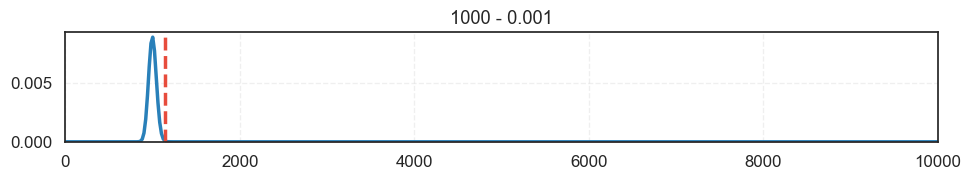

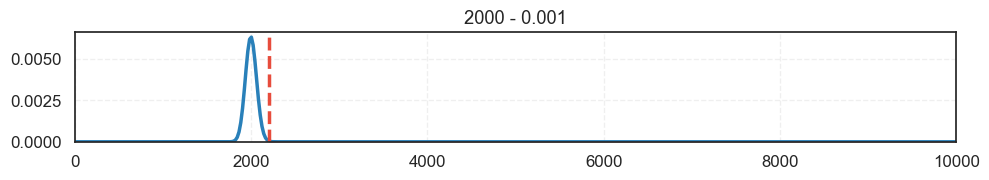

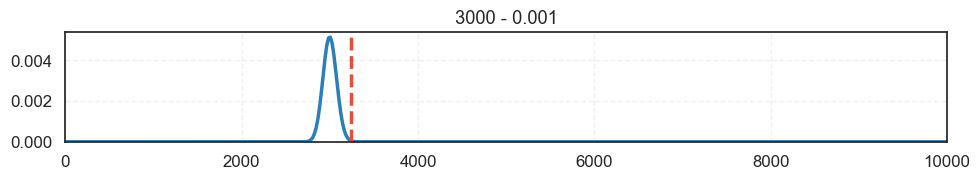

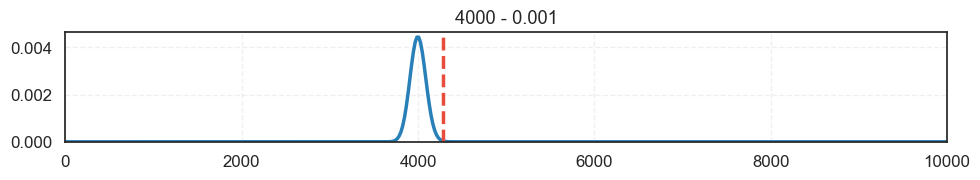

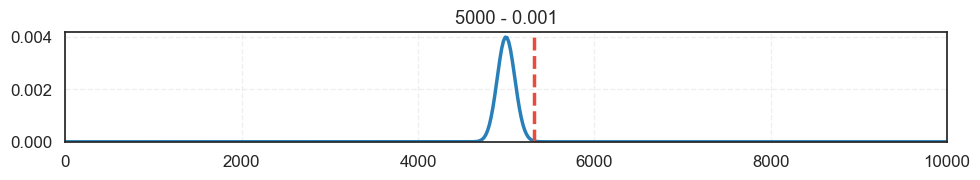

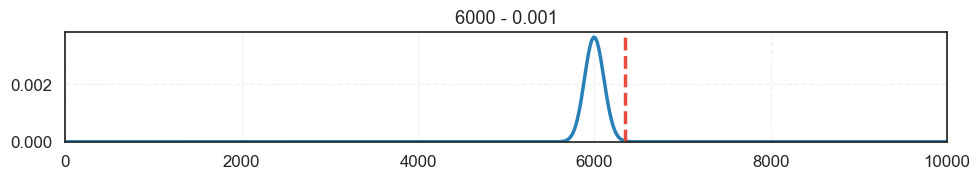

In [50]:
plot_chi_square(1000, 0.001)
plot_chi_square(2000, 0.001)
plot_chi_square(3000, 0.001)
plot_chi_square(4000, 0.001)
plot_chi_square(5000, 0.001)
plot_chi_square(6000, 0.001)